Importing the libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import mthree
from IPython.display import  display

Creating a noisy simulator

In [2]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError

p0given1 = 0.10
p1given0 = 0.05

# 1-qubit readout error matrix (2x2)
readout_error = ReadoutError([[1 - p1given0, p1given0], [p0given1, 1 - p0given1]])

noise_model = NoiseModel()

# Apply the 1-qubit error to qubit 0 and qubit 1 individually
for qubit in [0, 1]:
    noise_model.add_readout_error(readout_error, [qubit])

simulator = AerSimulator(noise_model=noise_model)

Building the calibration circuits

In [3]:
# Pass simulator directly as the first argument
mit = mthree.M3Mitigation(simulator)

# Run calibration specifically on qubits 0 and 1
mit.cals_from_system(qubits=[0, 1], shots=1024)
print("Calibration complete.")

Calibration complete.


Creating a test circuit

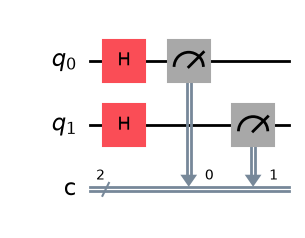

In [4]:
test_circuit = QuantumCircuit(2, 2)
test_circuit.h(0)
test_circuit.h(1)
test_circuit.measure([0, 1], [0, 1])

display(test_circuit.draw('mpl'))

Running without mitigation

Raw counts: {'11': 216, '00': 274, '10': 275, '01': 259}


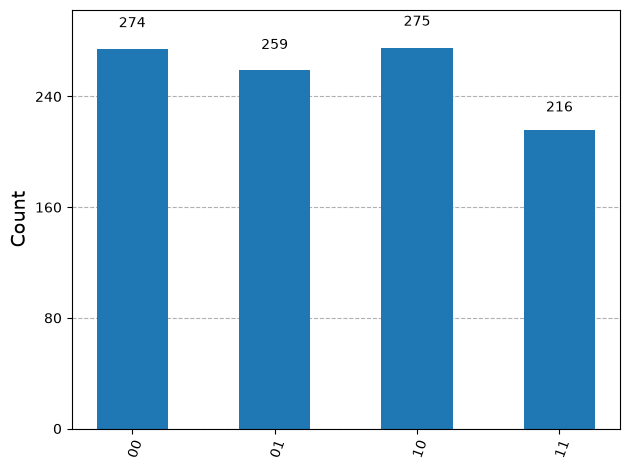

In [5]:
raw_results = simulator.run(test_circuit, shots=1024).result()
raw_counts = raw_results.get_counts()

print("Raw counts:", raw_counts)
plot_histogram(raw_counts)

Applying the mitigation filter

Mitigated probabilities: {'11': 0.22725076973438263, '00': 0.24052953720092773, '01': 0.2647583484649658, '10': 0.26746129989624023}


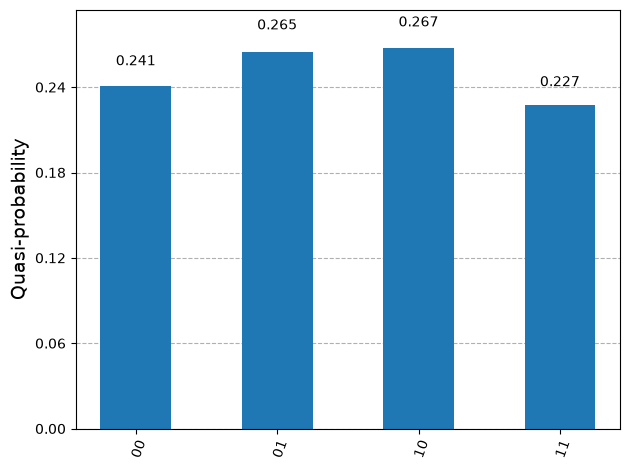

In [6]:
# 1. Apply M3 mitigation to raw counts
res = mit.apply_correction(raw_counts, qubits=[0, 1])
mit_counts = res.nearest_probability_distribution()

# 2. Convert values to standard python floats
mit_counts_clean = {k: float(v) for k, v in mit_counts.items()}

print("Mitigated probabilities:", mit_counts_clean)
plot_histogram(mit_counts_clean)

Checking the readout fidelity

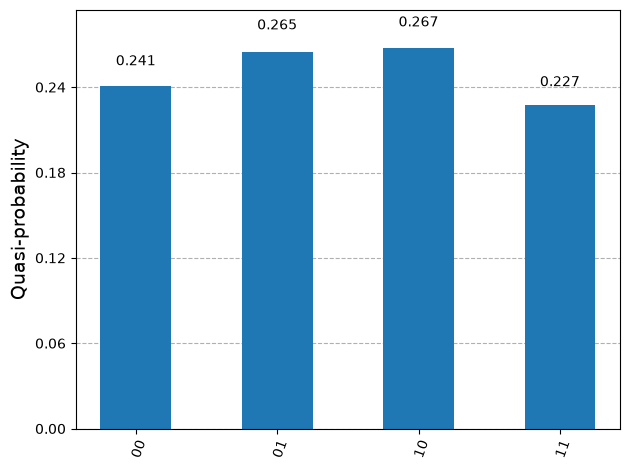

In [7]:
from qiskit.visualization import plot_histogram

# 1. Apply M3 mitigation
res = mit.apply_correction(raw_counts, qubits=[0, 1])

# 2. Convert to a standard Python dictionary with float values
mitigated_dict = {k: float(v) for k, v in res.nearest_probability_distribution().items()}

# 3. Plot and display the histogram
fig = plot_histogram(mitigated_dict)
display(fig)